<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap9_audioGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install genaibook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


9章　音声の生成

- テキストから音声（TTA）
- 音声クローン
- 音声分類
- 音声強調
- 音声翻訳
- 話者ダイアリゼーション

9.1 音声データ

LibriSpeech データセットを使ってみる。
音声データを扱うときはデータ量が膨大になりやすいので注意。

load_dataset_builder() を使えば全データを読み込まずにデータセットの構造を把握することができる。

In [2]:
from datasets import load_dataset_builder

ds_builder = load_dataset_builder(
    "openslr/librispeech_asr"
)
ds_builder.info.splits

README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

{'train.clean.100': SplitInfo(name='train.clean.100', num_bytes=6627791685, num_examples=28539, shard_lengths=None, dataset_name=None),
 'train.clean.360': SplitInfo(name='train.clean.360', num_bytes=23927767570, num_examples=104014, shard_lengths=None, dataset_name=None),
 'train.other.500': SplitInfo(name='train.other.500', num_bytes=31852502880, num_examples=148688, shard_lengths=None, dataset_name=None),
 'validation.clean': SplitInfo(name='validation.clean', num_bytes=359505691, num_examples=2703, shard_lengths=None, dataset_name=None),
 'validation.other': SplitInfo(name='validation.other', num_bytes=337213112, num_examples=2864, shard_lengths=None, dataset_name=None),
 'test.clean': SplitInfo(name='test.clean', num_bytes=368449831, num_examples=2620, shard_lengths=None, dataset_name=None),
 'test.other': SplitInfo(name='test.other', num_bytes=353231518, num_examples=2939, shard_lengths=None, dataset_name=None)}

In [3]:
ds_builder.info.features

{'file': Value('string'),
 'audio': Audio(sampling_rate=16000, decode=True, stream_index=None),
 'text': Value('string'),
 'speaker_id': Value('int64'),
 'chapter_id': Value('int64'),
 'id': Value('string')}

In [4]:
from datasets import load_dataset

ds = load_dataset(
    "openslr/librispeech_asr",
    split="train.clean.360",
    streaming=True,
)
sample = next(iter(ds))
sample

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

{'file': '/home/albert/.cache/huggingface/datasets/downloads/extracted/41321bb258f165f6163b1b0335f41c1ae65f86988d636209307b7ed94af929a4/1487-133273-0000.flac',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7de373079550>,
 'text': 'THE SECOND IN IMPORTANCE IS AS FOLLOWS SOVEREIGNTY MAY BE DEFINED TO BE THE RIGHT OF MAKING LAWS IN FRANCE THE KING REALLY EXERCISES A PORTION OF THE SOVEREIGN POWER SINCE THE LAWS HAVE NO WEIGHT',
 'speaker_id': 1487,
 'chapter_id': 133273,
 'id': '1487-133273-0000'}

In [5]:
array = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]

# 最初の５秒を得る
array = array[: sampling_rate * 5]
print(f"number of samples: {len(array)}, Values: {array}")

number of samples: 80000, Values: [9.1552734e-05 4.5776367e-04 5.1879883e-04 ... 7.0526123e-02 5.9204102e-02
 6.5032959e-02]


In [6]:
import IPython.display as ipd

ipd.Audio(data=array, rate=sampling_rate)

9.1.1 波形

librosa というライブラリを使って波形を描画してみよう

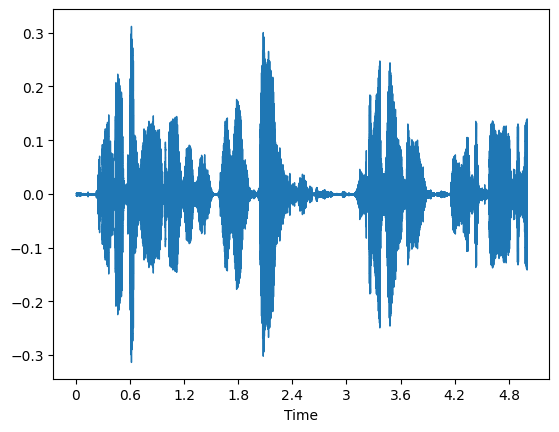

In [7]:
import librosa.display

librosa.display.waveshow(array, sr=sampling_rate);

9.1.2 スペクトログラム

スペクトログラムは波形とは異なる方法で音声信号を表現するもの。
本来は波形を入力とすることでモデルの訓練に使えるはずだがそうではない。
これは波形の次元の多さがある。波形は1次元ではあるが、膨大な数のデータポイントから構成されている。そのためモデルがデータのパターンや構造を学習しにくい。
波形は時間領域の情報は持っているものの、周波数成分に由来する属性は波形からだけだと判断することが非常に難しい。
ピッチや振幅は同じでも波形が異なると音色が異なる。
波形の違いを表現するためにスペクトログラムを用いる。

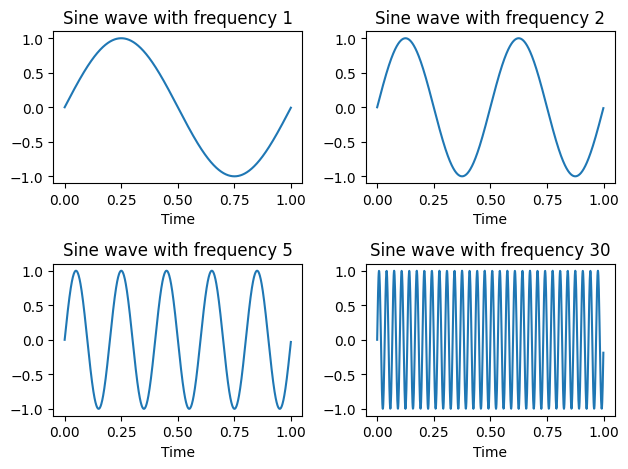

In [8]:
# スペクトログラムに入る前にまずは周波数についてみてみる。振幅の範囲は同じだが、周波数系が異なる４つの波形をプロットしてみる。

import numpy as np
from matplotlib import pyplot as plt

def plot_sine(freq):
  sr = 1000 #1秒あたりのサンプル数
  ts = 1.0 / sr #サンプリング間隔
  t = np.arange(0, 1, ts) #時間ベクトル
  amplitude = np.sin(2 * np.pi * freq * t)

  plt.plot(t, amplitude)
  plt.title("Sine wave with frequency {}".format(freq))
  plt.xlabel("Time")

fig = plt.figure()

plt.subplot(2, 2, 1)
plot_sine(1)

plt.subplot(2, 2, 2)
plot_sine(2)

plt.subplot(2, 2, 3)
plot_sine(5)

plt.subplot(2, 2, 4)
plot_sine(30)

fig.tight_layout()
plt.show()

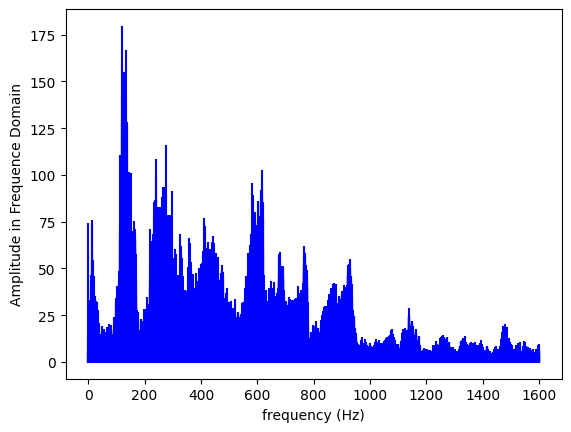

In [9]:
# 入力信号の高速フーリエ変換を計算
x = np.fft.fft(array)

# FFT の結果の長さ（入力信号の長さと同じ）
N = len(x)

# FFT の結果に対応する周波数ビンを計算
n = np.arange(N)
T = N / sampling_rate
freq = n / T

# 最初の８０００個の周波数ビンについて振幅スペクトルをプロット
# すべてのビンをプロットすることもできるが反転された形になる
plt.stem(freq[:8000], np.abs(x[:8000]), "b", markerfmt=" ", basefmt="-b")
plt.xlabel("frequency (Hz)")
plt.ylabel("Amplitude in Frequence Domain")
plt.show()

↑のフーリエ変換の図では時間の情報が失われている。
時間の情報と周波数、振幅の３つの情報を表現するときに使えるのがスペクトログラム。
時間ごとに区切り（スライディングウィンドウ）、の区間の周波数成分の変化を捉えるもの。
音声をスライディングウィンドウで処理するアプローチのことを短時間フーリエ変換と呼ぶ。
librosa を使えば stft() で短時間フーリエ変換を求められる。

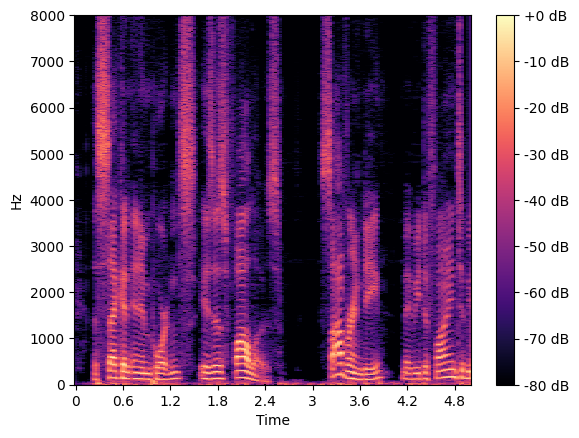

In [10]:
# 短時間フーリエ変換を計算
# STFT の絶対値を取ることで角周波数ビンの振幅を取得する
D = np.abs(librosa.stft(array))

# 振幅をdBに変換する
# dBは対数スケールである
S_sb = librosa.amplitude_to_db(D, ref=np.max)

# スペクトログラムを表示する
librosa.display.specshow(S_sb, sr=sampling_rate, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB");

スペクトログラムの中でもよく使われるバリエーションの一つにメルスペクトログラムがある。
これは人間が知覚している方法に似たスケールを適用する方法。
人間は対数的に音を知覚するので低周波の音には敏感だが、高周波の音には鈍感。500Hz と 1000Hz の差には敏感だが、5000Hz と 5500Hz の差には鈍感。

librosa ではメルスペクトログラムを求めるためのメソッドもあるので使ってみる。

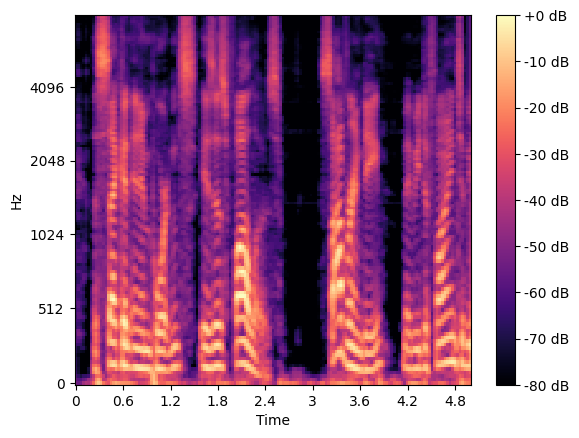

In [11]:
# 音声信号からメルスペクトログラムを生成する
# 結果は各要素が特定の時刻における周波数帯（メルスケール）の強さを表す行列となる
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate)

# スペクトログラムをdBスケールに変換する
S_dB = librosa.power_to_db(S, ref=np.max)

# メルスペクトログラムを表示する
librosa.display.specshow(S_dB, sr=sampling_rate, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")

9.2 Transformer ベースのアーキテクチャーによる音声テキスト変換

ここからは ASR（音声ファイルをテキストに書き起こすタスク）についてみていく。
他のタスクと同様に transformer の pipeline を使うことで実践できる。
人気のモデルである Whisper を使ってみる。

In [12]:
from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    max_new_tokens=200
)
pipe(array)

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugg

{'text': ' The second in importance is as follows. Sovereignty may be defined to be'}

文字起こしがちゃんとできていることがわかる。
しかも元の音声は最後「be」で終わっているのに単語全体を正しく予測できている。
さらに、句読点まで正しく予測している。

Whisper の詳細に入る前にエンコーダー専用モデルが ASR にどのように活用できるのかをみていく。

9.2.1 エンコーダーベースの手法

ASR（音声をテキストに書き起こすタスク）はテキストトークンの分類タスクのように捉えることができる。
テキストの学習と同じように、音声も一部をマスキングして事前訓練させ、このモデルに対してラベル付きデータでファインチューニングさせる手法がある。

音声サンプルの場合、巨大な配列になる課題がある。これを緩和するために CNN を特徴エンコーダーとして用いる。入力データをスライドしながら処理し、潜在的な音声表現を出力するようにする。事前訓練時にはこの入力の一部がマスクされるので、このマスクされた部分の潜在表現を予測するように学習する。

ファインチューニングの際はエンコーダーの後ろに線形分類ヘッドが追加される。分類機の目標はエンコーダーで処理した音声に対応するテキストを推定すること。単語レベルの長さで推定するには音声データが巨大なので、文字単位の推定を行うことが推奨される。

この方法でテキストを出力すると、`CHAAAAPTEEERRRRSSSIXTEEEEENIMMMIIGHT` のように同じ文字が不必要に複数回出現してしまう。
これに対するアプローチとして、元々 RNN で使われていたConnectionist Temporal Classification (CTC) を使って解決する。
パディング用のトークンを追加して文字のグループの境界を示し、単語の区切りをセパレーターで区切るというもの。これにより目的とする結果が得られるようになる。
この辺りのアイデアは Word2Vec2 や HuBERT などの基礎をなしている。

以下のコードは Word2Vec による推論のステップを示したもの。

In [13]:
import torch
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

from genaibook.core import get_device

device = get_device()

# Wav2Vec2Processor には前処理や後処理が組み込まれている
wav2vec2_processor = Wav2Vec2Processor.from_pretrained(
  "facebook/wav2vec2-base-960h"
)
wav2vec2_model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
).to(device)

# 16kHzにリサンプリングして準伝搬を実行する
inputs = wav2vec2_processor(
    array, sampling_rate=sampling_rate, return_tensors="pt"
)
with torch.inference_mode():
  outputs = wav2vec2_model(**inputs.to(device))

# 文字起こし
predicted_ids = torch.argmax(outputs.logits, dim=-1)
transcription = wav2vec2_processor.batch_decode(predicted_ids)
print(transcription)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['THE SECOND IN IMPORTANCE IS AS FOLLOWS SOVEREIGNTY MAY BE DEFINED TO']


9.2.2 エンコーダー・デコーダー型の手法

音響モデルはスペルミスを生みやすいため、n-gram モデルを組み込む必要がある。
Whisper はスペクトログラムを用いて動作する。まず音声サンプルに対してパディングや切り詰めを行い入力長を揃え、それらをメルスペクトログラムに変換し CNN で処理してからエンコーダーへ渡す。その後 encoderの出力はデコーダーへと渡され、デコーダーは１つずつのトークンを自己回帰的に予測していき、終了トークンが生成されるまでこれを繰り返す。

スペイン語の例とそれに対応する形式を見てみる。

In [14]:
from transformers import WhisperTokenizer

tokenizer = WhisperTokenizer.from_pretrained(
    "openai/whisper-small",
  language="Spanish",
  task="transcribe",
)

input_str = "Hola, ¿cómo estás"
labels = tokenizer(input_str).input_ids
decoded_with_special = tokenizer.decode(
    labels,
    skip_special_tokens=False,
)
decoded_str = tokenizer.decode(labels, skip_special_tokens=True)

print(f"Input:                   {input_str}")
print(f"Formatted w/ special:    {decoded_with_special}")
print(f"Formatted w/out special: {decoded_str}")

Input:                   Hola, ¿cómo estás
Formatted w/ special:    <|startoftranscript|><|es|><|transcribe|><|notimestamps|>Hola, ¿cómo estás<|endoftext|>
Formatted w/out special: Hola, ¿cómo estás


次に実際にモデルとプロセッサーをロードして文字起こしを行うコードを見ていく。

In [15]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor

whisper_processor = WhisperProcessor.from_pretrained("openai/whisper-small")
whisper_model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"
).to(device)

inputs = whisper_processor(
    array, sampling_rate=sampling_rate, return_tensors="pt"
)
with torch.inference_mode():
  generated_ids = whisper_model.generate(**inputs.to(device))

transcription = whisper_processor.batch_decode(
    generated_ids, skip_special_tokens=False
)[0]
print(transcription)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


 The second in importance is as follows. Sovereignty may be defined to be


9.2.3 モデルからパイプラインへ

実際に文字起こしするにはいくつかまだ課題があるが、それぞれへの対策についても可能。
- 長時間音声の文字起こし：チャンクに分割することで対応可能。チャンクに分割してストライドさせることで精度も一定担保できる。
- ライブ推論：チャンク化することで細かく小さな単位で推論させられる。
- タイムスタンプ：音声区間ごとに開始と終了のタイムスタンプを持たせることで対応可能。

これらの手法を組み合わせて１分間の長い音声データを処理してみる。

In [17]:
from genaibook.core import generate_long_audio

long_audio = generate_long_audio()

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

HfUriError: Invalid HF URI 'hf://datasets/librispeech_asr@71cacbfb7e2354c4226d01e70d77d5fca3d04ba1/.huggingface.yaml'. Repository id must be 'namespace/name', got 'librispeech_asr'.

In [16]:
device = get_device()

pipe = pipeline(
    "automatic-speech-recognition", model="openai/whisper-small", device=device
)
pipe(
  long_audio,
  generate_kwargs={"task": "transcribe"},
  chunk_length_s=5,
  batch_size=8,
  return_timestamps=True
)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

NameError: name 'long_audio' is not defined